In [1]:
import sys
sys.path.append("../../src")

In [2]:
import numpy as np
from gaussian_systems.initial_state import GaussianCVState
from gaussian_systems.systems import GaussianCVSystem, single_pole_ou_embedding

In [3]:
n = 2 #system size

#state parameters
ra, rb = ( (1.0,0.0), (1.0,0.0))
da, db = ( (1/np.sqrt(2))*(3+3j), (1/np.sqrt(2))*(-3-3j))

#environment parameters
kappa = 1
delta_E, delta_2 = 0.1*kappa, 0.1*kappa
frequency_array = np.array([0,delta_2])
gamma = 0.5*kappa
n_bar = 0

In [4]:
#use GaussianCVState constructor to generate the mean and covariance matrix
my_state = GaussianCVState.vacuum(n)
my_state.single_mode_squeeze(ra,1).single_mode_squeeze(rb,2)
my_state.single_mode_displacement(da,1).single_mode_displacement(db,2)

In [5]:
#use GaussianCVSystem constructor to generate the hamiltonian and linbladian matrix
my_system = GaussianCVSystem.free_evolution(n,frequency_array)

In [6]:
#use single_poled_ou_embedding to embed your n-mode state+system into an n+1 mode state+system
#where the n+1-th mode corresponds to an OU memory kernel with a single central frequency 
embedded_state, embedded_system = single_pole_ou_embedding(
    state=my_state, 
    system=my_system,
    subsystem=(1,2),
    coupling_types=("annihilation","annihilation"),
    memory_rate=gamma,
    env_freq=delta_E,
    decay_rate=kappa, 
    thermal_occupation=n_bar
)

<Axes: >

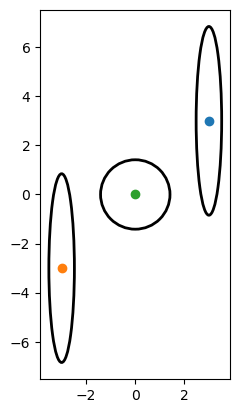

In [7]:
# GaussianCVState is also equipped with basic ellipse plotting for all modes encoded in the object
embedded_state.plot_state()

In [8]:
# For time-independent (only choice implemented as of 3/19/26) GaussianCVSystems
# evolution can be simulated using an analytical mapping. This is implemented
# with GaussianCVSystem.evolve_state(GaussianCVState, t_eval) and returns
# GaussianSolution object is defined by the t_eval, and time traces of the mean vector 
# and covariance matrix
t_eval = np.linspace(0,20/delta_2,1000)
solution_obj = embedded_system.evolve_state(embedded_state, t_eval)

In [9]:
# The GaussianSolution object encodes the logic of various Gaussian metrics
# The below example gives the log neg time trace and entropy of the reduced 1+2 subsystem 
# (effectively removing the pseudomode)
ents = solution_obj.entanglement_time_trace()
purities = solution_obj.purity_time_trace((1,2))

In [10]:
import matplotlib.pyplot as plt

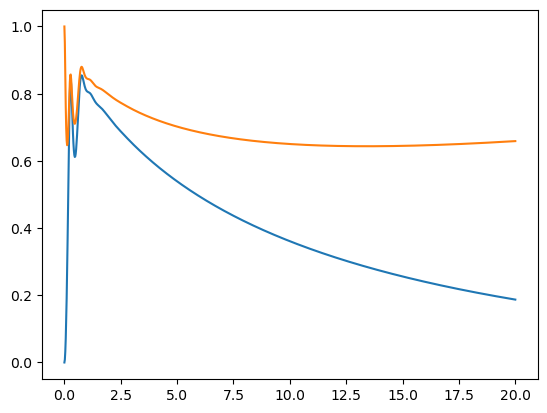

In [11]:
plt.plot(t_eval*delta_2,ents, t_eval*delta_2,purities)

In [12]:
#GaussianCVSystem handles Markovian dissipation internally
my_system.multi_annihilation_dissipator((1,2), 1)

In [13]:
#The same evolve_state simulates the dynamics and create a new GaussianSolution object
solution_markov = my_system.evolve_state(my_state, t_eval)

In [14]:
ents_m = solution_markov.entanglement_time_trace()
purities_m = solution_markov.purity_time_trace()

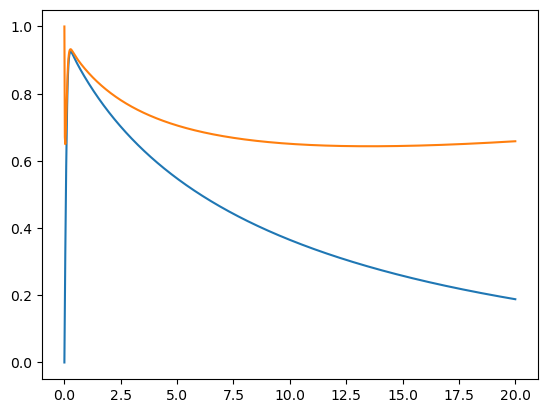

In [15]:
plt.plot(t_eval*delta_2,ents_m, t_eval*delta_2, purities_m)